
## Objectives

After completing this lab you will be able to:

*   Develop a various classification algorithms

In this lab exercise, you will learn a various classification machine learning algorithms. You will use the classification algorithms to build a model from the historical data of patients, and their response to different medications. Then you will use the trained decision tree to predict the class of an unknown patient, or to find a proper drug for a new patient.


<h1>Table of contents</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="https://#about_dataset">About the dataset</a></li>
        <li><a href="https://#downloading_data">Downloading the Data</a></li>
        <li><a href="https://#pre-processing">Pre-processing</a></li>
        <li><a href="https://#setting_up_tree">Setting up the Decision Tree</a></li>
        <li><a href="https://#modeling">Modeling</a></li>
        <li><a href="https://#prediction">Prediction</a></li>
        <li><a href="https://#evaluation">Evaluation</a></li>
        <li><a href="https://#visualization">Visualization</a></li>
    </ol>
</div>
<br>
<hr>


Import the Following Libraries:

<ul>
    <li> <b>numpy as np</b> </li>
    <li> <b>pandas as pd</b> </li>
    <li> <b>matplotlib.pyplot as plt</b> </li>
    <li> <b>seaborn as sns</b> </li>
    <li> <b>train_test_split</b> from <b>sklearn.model_selection</b> </li>
    <li> <b>LabelEncoder or OneHotEncoder</b> (which ever you prefer) from <b>sklearn.preprocessing</b> </li>
    <li> <b>GausianNB</b> from <b>sklearn.naive_bayes</b> </li>
    <li> <b>metrics</b> from <b>sklearn.metrics</b> </li>

</ul>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, CategoricalNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

<div id="about_dataset">
    <h2>About the dataset</h2>
    Imagine that you are a medical researcher compiling data for a study. You have collected data about a set of patients, all of whom suffered from the same illness. During their course of treatment, each patient responded to one of 5 medications, Drug A, Drug B, Drug c, Drug x and y.
    <br>
    <br>
    Part of your job is to build a model to find out which drug might be appropriate for a future patient with the same illness. The features of this dataset are Age, Sex, Blood Pressure, and the Cholesterol of the patients, and the target is the drug that each patient responded to.
    <br>
    <br>
    It is a sample of multiclass classifier, and you can use the training part of the dataset
    to build a decision tree, and then use it to predict the class of an unknown patient, or to prescribe a drug to a new patient.
    <br>
    Typical features in the dataset:
     <li>Age (numeric)
     <li>Sex (categorical: M, F)
     <li>BP (categorical: HIGH, NORMAL, LOW)
     <li>Cholesterol (categorical: HIGH, NORMAL)
     <li>Na_to_K (numeric: Sodium/Potassium ratio)
     <li>Drug (target label)
</div>


<div id="downloading_data">
    <h2>Load the Data</h2>
</div>

Now, load the data using pandas dataframe:


In [2]:
drug = pd.read_csv('drug200.csv')

In [3]:
drug

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


<div id="Explore the data">
    <h3>Explore the data</h3>
    What is the size of data?
    What is the data descriptive?
</div>


In [4]:
# write your code here
print("the dataset is: ",drug.shape)
print("the dataset description is:", drug.describe(include='all'))

the dataset is:  (200, 6)
the dataset description is:                Age  Sex    BP Cholesterol     Na_to_K   Drug
count   200.000000  200   200         200  200.000000    200
unique         NaN    2     3           2         NaN      5
top            NaN    M  HIGH        HIGH         NaN  drugY
freq           NaN  104    77         103         NaN     91
mean     44.315000  NaN   NaN         NaN   16.084485    NaN
std      16.544315  NaN   NaN         NaN    7.223956    NaN
min      15.000000  NaN   NaN         NaN    6.269000    NaN
25%      31.000000  NaN   NaN         NaN   10.445500    NaN
50%      45.000000  NaN   NaN         NaN   13.936500    NaN
75%      58.000000  NaN   NaN         NaN   19.380000    NaN
max      74.000000  NaN   NaN         NaN   38.247000    NaN


<div href="pre-processing">
    <h2>Pre-processing</h2>
</div>


Using <b>my_data</b> as the Drug.csv data read by pandas, declare the following variables: <br>

<ul>
    <li> <b> X </b> as the <b> Feature Matrix </b> (data of my_data) </li>
    <li> <b> X </b> is 'Age', 'Sex_n', 'BP_n', 'Chol_n', 'Na_to_K'</li>
    <li> <b> Y </b> as the <b> response vector </b> (target) </li>
    <li> Y is 'Drug'</li>
</ul>


Remove the column containing the target name since it doesn't contain numeric values.


In [5]:
#split data into X and Y
x = drug.iloc[:,:-1]
y = drug.iloc[:,-1]
print(x)
print(y)

     Age Sex      BP Cholesterol  Na_to_K
0     23   F    HIGH        HIGH   25.355
1     47   M     LOW        HIGH   13.093
2     47   M     LOW        HIGH   10.114
3     28   F  NORMAL        HIGH    7.798
4     61   F     LOW        HIGH   18.043
..   ...  ..     ...         ...      ...
195   56   F     LOW        HIGH   11.567
196   16   M     LOW        HIGH   12.006
197   52   M  NORMAL        HIGH    9.894
198   23   M  NORMAL      NORMAL   14.020
199   40   F     LOW      NORMAL   11.349

[200 rows x 5 columns]
0      drugY
1      drugC
2      drugC
3      drugX
4      drugY
       ...  
195    drugC
196    drugC
197    drugX
198    drugX
199    drugX
Name: Drug, Length: 200, dtype: object


As you may figure out, some features in this dataset are categorical, such as **Sex** or **BP**. Convert the categorical variable into dummy/indicator variables.


In [6]:
#label encoder or OneHotEncoder for Sex, BP and Cholesterol
#label encoder or OneHotEncoder for Sex, BP and Cholesterol
le_sex = LabelEncoder()
le_BP = LabelEncoder()
le_Chol = LabelEncoder()

drug['Sex'] = le_sex.fit_transform(drug['Sex'])
drug['BP'] = le_BP.fit_transform(drug['BP'])
drug['Cholesterol'] = le_Chol.fit_transform(drug['Cholesterol'])

X = drug[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']].values
Y = drug['Drug']
print(X)

[[23.     0.     0.     0.    25.355]
 [47.     1.     1.     0.    13.093]
 [47.     1.     1.     0.    10.114]
 [28.     0.     2.     0.     7.798]
 [61.     0.     1.     0.    18.043]
 [22.     0.     2.     0.     8.607]
 [49.     0.     2.     0.    16.275]
 [41.     1.     1.     0.    11.037]
 [60.     1.     2.     0.    15.171]
 [43.     1.     1.     1.    19.368]
 [47.     0.     1.     0.    11.767]
 [34.     0.     0.     1.    19.199]
 [43.     1.     1.     0.    15.376]
 [74.     0.     1.     0.    20.942]
 [50.     0.     2.     0.    12.703]
 [16.     0.     0.     1.    15.516]
 [69.     1.     1.     1.    11.455]
 [43.     1.     0.     0.    13.972]
 [23.     1.     1.     0.     7.298]
 [32.     0.     0.     1.    25.974]
 [57.     1.     1.     1.    19.128]
 [63.     1.     2.     0.    25.917]
 [47.     1.     1.     1.    30.568]
 [48.     0.     1.     0.    15.036]
 [33.     0.     1.     0.    33.486]
 [28.     0.     0.     1.    18.809]
 [31.     1.

Print the target variable.


In [7]:
#print y
print(y)

0      drugY
1      drugC
2      drugC
3      drugX
4      drugY
       ...  
195    drugC
196    drugC
197    drugX
198    drugX
199    drugX
Name: Drug, Length: 200, dtype: object


<hr>

<div id="Model Setting">
    <h2>Setting up the Naive Bayes Algorithm</h2>
    We will be using <b>train/test split</b> on our algorithms </b>. Let's import <b>train_test_split</b> from <b>sklearn.model_selection</b>.
</div>


Now <b> train_test_split </b> will return 4 different parameters. We will name them:<br>
X_trainset, X_testset, Y_trainset, Y_testset <br> <br>
The <b> train_test_split </b> will need the parameters: <br>
X, y, test_size=0.3, and random_state=3. <br> <br>
The <b>X</b> and <b>y</b> are the arrays required before the split, the <b>test_size</b> represents the ratio of the testing dataset, and the <b>random_state</b> ensures that the dataset were split at random with consistent shuffle.


In [8]:
#write your code here
X_trainset, X_testset, Y_trainset, Y_testset = train_test_split(X, Y, test_size=0.3, random_state=3)

Print the shape of X_trainset and y_trainset. Ensure that the dimensions match the prior splitting request.


In [9]:
print('Shape of X training set {}'.format(X_trainset.shape),'&',' Size of Y training set {}'.format(Y_trainset.shape))


Shape of X training set (140, 5) &  Size of Y training set (140,)



Print the shape of X_testset and y_testset.


In [10]:
# your code

print('Shape of X training set {} &  Size of Y training set {}'.format(X_testset.shape, Y_testset.shape))

Shape of X training set (60, 5) &  Size of Y training set (60,)


<hr>

<div id="modeling">
    <h2>Modeling</h2>
    Lets create an instance of the <b>Naive Bayes</b>.

</div>


In [11]:
# Create a Naive Bayes classifier and name it as Model_NB1

Model_NB1 = GaussianNB()

Next, we will fit the data with the training feature matrix <b> X_trainset </b> and training  response vector <b> y_trainset </b>


In [12]:
# Train the classifier with X_trainset and Y_trainset

Model_NB1.fit(X_trainset, Y_trainset)

GaussianNB()

<hr>

<div id="prediction">
    <h2>Prediction</h2>
    Let's make some <b>predictions</b> on the testing dataset and store it into a variable called <b>predNB1</b>.
</div>


In [13]:
#make prediction for Model_NB1 (Naive Bayes)

predNB1 = Model_NB1.predict(X_testset)

You can print out <b>predNB1</b> and <b>y_testset</b> if you want to visually compare the predictions to the actual values.





In [14]:
#Compare the predicted Y for Model_NB1 vs Actual Y Test

print(predNB1)
print(Y_testset)

['drugY' 'drugX' 'drugX' 'drugX' 'drugX' 'drugC' 'drugA' 'drugA' 'drugB'
 'drugA' 'drugY' 'drugA' 'drugY' 'drugY' 'drugX' 'drugY' 'drugX' 'drugX'
 'drugB' 'drugX' 'drugX' 'drugB' 'drugC' 'drugY' 'drugX' 'drugB' 'drugY'
 'drugY' 'drugA' 'drugX' 'drugB' 'drugC' 'drugC' 'drugX' 'drugX' 'drugC'
 'drugC' 'drugX' 'drugX' 'drugX' 'drugA' 'drugA' 'drugC' 'drugA' 'drugA'
 'drugY' 'drugY' 'drugY' 'drugC' 'drugY' 'drugB' 'drugX' 'drugY' 'drugX'
 'drugY' 'drugB' 'drugA' 'drugX' 'drugY' 'drugX']
40     drugY
51     drugX
139    drugX
197    drugX
170    drugX
82     drugC
183    drugY
46     drugA
70     drugB
100    drugA
179    drugY
83     drugA
25     drugY
190    drugY
159    drugX
173    drugY
95     drugX
3      drugX
41     drugB
58     drugX
14     drugX
143    drugY
12     drugY
6      drugY
182    drugX
161    drugB
128    drugY
122    drugY
101    drugA
86     drugX
64     drugB
47     drugC
158    drugC
34     drugX
38     drugX
196    drugC
4      drugY
72     drugX
67     drugX
145  

<hr>

<div id="evaluation">
    <h2>Evaluation</h2>
    Next, let's check the accuracy of our model.
</div>


In [15]:
#check the confusion matrix

conf = confusion_matrix(Y_testset, predNB1, )
print(conf)

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 3  2  3  0 14]]


In [16]:
#check the accuracy

acc = accuracy_score(Y_testset, predNB1)
print(acc)

0.85


In [17]:
#check the classification report

report = classification_report(Y_testset, predNB1)
print(report)

              precision    recall  f1-score   support

       drugA       0.70      1.00      0.82         7
       drugB       0.71      1.00      0.83         5
       drugC       0.62      1.00      0.77         5
       drugX       1.00      0.95      0.98        21
       drugY       0.93      0.64      0.76        22

    accuracy                           0.85        60
   macro avg       0.79      0.92      0.83        60
weighted avg       0.89      0.85      0.85        60



**Accuracy classification score** computes subset accuracy: the set of labels predicted for a sample must exactly match the corresponding set of labels in y_true.

In multilabel classification, the function returns the subset accuracy. If the entire set of predicted labels for a sample strictly matches with the true set of labels, then the subset accuracy is 1.0; otherwise it is 0.0.


<hr>

<div id="visualization">
    <h2>Visualization</h2>

Let's visualize Confusion Matrix using heatmap.

</div>


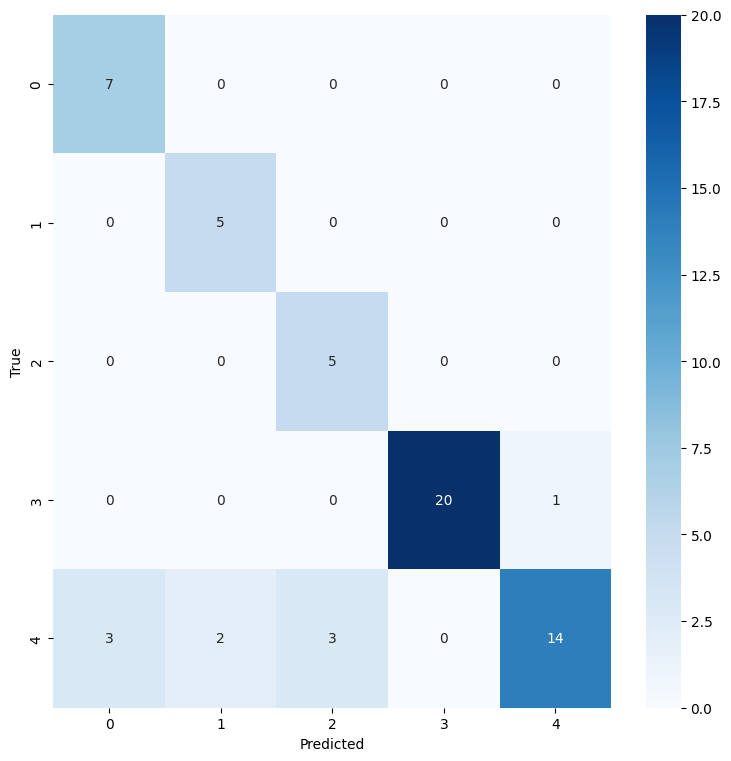

In [18]:
#heatmap for confusion matrix

plt.figure(figsize=(9,9))
sns.heatmap(conf, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()



# Another variant of Naive Bayes

In [19]:
# try to set the parameter such as var_smoothing or alpha in the models
# let try using another variant of naive bayes such as Multinomial and Bernoulli
# split the data using cross validation technique
# compare the performance of each models

In [32]:
#make prediction for Model_NB2 (Multinomial Naive Bayes)
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

Model_NB2 = MultinomialNB()
Model_NB2.fit(X_trainset, Y_trainset)
predNB2 = Model_NB2.predict(X_testset)

print("Multinomial Naive Bayes Confusion Matrix:")
print(confusion_matrix(Y_testset, predNB2))

print("\nMultinomial Naive Bayes Accuracy:")
print(accuracy_score(Y_testset, predNB2))

print("\nMultinomial Naive Bayes Classification Report:")
print(classification_report(Y_testset, predNB2))

Multinomial Naive Bayes Confusion Matrix:
[[ 4  0  0  0  3]
 [ 1  4  0  0  0]
 [ 0  0  0  4  1]
 [ 0  0  0 15  6]
 [ 4  1  2  5 10]]

Multinomial Naive Bayes Accuracy:
0.55

Multinomial Naive Bayes Classification Report:
              precision    recall  f1-score   support

       drugA       0.44      0.57      0.50         7
       drugB       0.80      0.80      0.80         5
       drugC       0.00      0.00      0.00         5
       drugX       0.62      0.71      0.67        21
       drugY       0.50      0.45      0.48        22

    accuracy                           0.55        60
   macro avg       0.47      0.51      0.49        60
weighted avg       0.52      0.55      0.53        60



In [33]:
#make prediction for Model_NB3 (Categorical Naive Bayes)
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

Model_NB3 = CategoricalNB()
Model_NB3.fit(X_trainset, Y_trainset)
predNB3 = Model_NB3.predict(X_testset)

print("Categorical Naive Bayes Confusion Matrix:")
print(confusion_matrix(Y_testset, predNB3))

print("\nCategorical Naive Bayes Accuracy:")
print(accuracy_score(Y_testset, predNB3))

print("\nCategorical Naive Bayes Classification Report:")
print(classification_report(Y_testset, predNB3))

Categorical Naive Bayes Confusion Matrix:
[[ 1  4  0  0  2]
 [ 1  2  0  0  2]
 [ 0  0  3  2  0]
 [ 0  0  0 21  0]
 [ 0  0  0  0 22]]

Categorical Naive Bayes Accuracy:
0.8166666666666667

Categorical Naive Bayes Classification Report:
              precision    recall  f1-score   support

       drugA       0.50      0.14      0.22         7
       drugB       0.33      0.40      0.36         5
       drugC       1.00      0.60      0.75         5
       drugX       0.91      1.00      0.95        21
       drugY       0.85      1.00      0.92        22

    accuracy                           0.82        60
   macro avg       0.72      0.63      0.64        60
weighted avg       0.80      0.82      0.79        60



In [34]:
#make prediction for Model_NB5 (Gaussian Naive Bayes) with alpha
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

Model_NB5 = GaussianNB(var_smoothing=1e-9)
Model_NB5.fit(X_trainset, Y_trainset)
predNB5 = Model_NB5.predict(X_testset)

print("Gaussian Naive Bayes (var_smoothing=1e-9) Confusion Matrix:")
print(confusion_matrix(Y_testset, predNB5))

print("\nGaussian Naive Bayes (var_smoothing=1e-9) Accuracy:")
print(accuracy_score(Y_testset, predNB5))

print("\nGaussian Naive Bayes (var_smoothing=1e-9) Classification Report:")
print(classification_report(Y_testset, predNB5))

Gaussian Naive Bayes (var_smoothing=1e-9) Confusion Matrix:
[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 3  2  3  0 14]]

Gaussian Naive Bayes (var_smoothing=1e-9) Accuracy:
0.85

Gaussian Naive Bayes (var_smoothing=1e-9) Classification Report:
              precision    recall  f1-score   support

       drugA       0.70      1.00      0.82         7
       drugB       0.71      1.00      0.83         5
       drugC       0.62      1.00      0.77         5
       drugX       1.00      0.95      0.98        21
       drugY       0.93      0.64      0.76        22

    accuracy                           0.85        60
   macro avg       0.79      0.92      0.83        60
weighted avg       0.89      0.85      0.85        60



# Logistic Regression

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

LR_model = LogisticRegression(solver='liblinear')
LR_model.fit(X_trainset, Y_trainset)
pred_LR = LR_model.predict(X_testset)

print("Logistic Regression (liblinear) Confusion Matrix:")
print(confusion_matrix(Y_testset, pred_LR))

print("\nLogistic Regression (liblinear) Accuracy:")
print(accuracy_score(Y_testset, pred_LR))

print("\nLogistic Regression (liblinear) Classification Report:")
print(classification_report(Y_testset, pred_LR))

Logistic Regression (liblinear) Confusion Matrix:
[[ 4  0  0  0  3]
 [ 0  5  0  0  0]
 [ 0  0  1  3  1]
 [ 0  0  0 21  0]
 [ 0  1  0  2 19]]

Logistic Regression (liblinear) Accuracy:
0.8333333333333334

Logistic Regression (liblinear) Classification Report:
              precision    recall  f1-score   support

       drugA       1.00      0.57      0.73         7
       drugB       0.83      1.00      0.91         5
       drugC       1.00      0.20      0.33         5
       drugX       0.81      1.00      0.89        21
       drugY       0.83      0.86      0.84        22

    accuracy                           0.83        60
   macro avg       0.89      0.73      0.74        60
weighted avg       0.86      0.83      0.81        60



Another variant of Logistic Regression

In [36]:
# make prediction for Logistic Regression (newton-cg)
LR_model2 = LogisticRegression(solver='newton-cg', max_iter=1000)
LR_model2.fit(X_trainset, Y_trainset)
pred_LR2 = LR_model2.predict(X_testset)

print("Logistic Regression (newton-cg) Confusion Matrix:")
print(confusion_matrix(Y_testset, pred_LR2))

print("\nLogistic Regression (newton-cg) Accuracy:")
print(accuracy_score(Y_testset, pred_LR2))

print("\nLogistic Regression (newton-cg) Classification Report:")
print(classification_report(Y_testset, pred_LR2))

Logistic Regression (newton-cg) Confusion Matrix:
[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 1  0  0  0 21]]

Logistic Regression (newton-cg) Accuracy:
0.9666666666666667

Logistic Regression (newton-cg) Classification Report:
              precision    recall  f1-score   support

       drugA       0.88      1.00      0.93         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.95      0.98        21
       drugY       0.95      0.95      0.95        22

    accuracy                           0.97        60
   macro avg       0.97      0.98      0.97        60
weighted avg       0.97      0.97      0.97        60



# Decison Tree

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

DT_model = DecisionTreeClassifier(criterion="entropy", max_depth=4)
DT_model.fit(X_trainset, Y_trainset)
pred_DT = DT_model.predict(X_testset)

print("Decision Tree (Entropy) Confusion Matrix:\n")
print(confusion_matrix(Y_testset, pred_DT))

print("\nDecision Tree (Entropy) Accuracy:")
print(accuracy_score(Y_testset, pred_DT))

print("\nDecision Tree (Entropy) Classification Report:")
print(classification_report(Y_testset, pred_DT))

Decision Tree (Entropy) Confusion Matrix:

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 0  0  0  0 22]]

Decision Tree (Entropy) Accuracy:
0.9833333333333333

Decision Tree (Entropy) Classification Report:
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.95      0.98        21
       drugY       0.96      1.00      0.98        22

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        60
weighted avg       0.98      0.98      0.98        60



Another variant of Decision Tree

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

DT_model2 = DecisionTreeClassifier(criterion="gini", max_depth=4)
DT_model2.fit(X_trainset, Y_trainset)
pred_DT2 = DT_model2.predict(X_testset)

print("Decision Tree (Gini) Confusion Matrix:\n")
print(confusion_matrix(Y_testset, pred_DT2))

print("\nDecision Tree (Gini) Accuracy:")
print(accuracy_score(Y_testset, pred_DT2))

print("\nDecision Tree (Gini) Classification Report:")
print(classification_report(Y_testset, pred_DT2))

Decision Tree (Gini) Confusion Matrix:

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 0  0  0  0 22]]

Decision Tree (Gini) Accuracy:
0.9833333333333333

Decision Tree (Gini) Classification Report:
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.95      0.98        21
       drugY       0.96      1.00      0.98        22

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        60
weighted avg       0.98      0.98      0.98        60



# Random Forest

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

RF_model = RandomForestClassifier(n_estimators=100, random_state=3)
RF_model.fit(X_trainset, Y_trainset)
pred_RF = RF_model.predict(X_testset)

print("Random Forest Confusion Matrix:\n")
print(confusion_matrix(Y_testset, pred_RF))

print("\nRandom Forest Accuracy:")
print(accuracy_score(Y_testset, pred_RF))

print("\nRandom Forest Classification Report:")
print(classification_report(Y_testset, pred_RF))

Random Forest Confusion Matrix:

[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 0  0  0  0 22]]

Random Forest Accuracy:
0.9833333333333333

Random Forest Classification Report:
              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.95      0.98        21
       drugY       0.96      1.00      0.98        22

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        60
weighted avg       0.98      0.98      0.98        60



# KNN

In [40]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

KNN_model = KNeighborsClassifier(n_neighbors=5)
KNN_model.fit(X_trainset, Y_trainset)
pred_KNN = KNN_model.predict(X_testset)

print("KNN Confusion Matrix:\n")
print(confusion_matrix(Y_testset, pred_KNN))

print("\nKNN Accuracy:")
print(accuracy_score(Y_testset, pred_KNN))

print("\nKNN Classification Report:")
print(classification_report(Y_testset, pred_KNN))

KNN Confusion Matrix:

[[ 4  0  1  2  0]
 [ 0  5  0  0  0]
 [ 2  2  0  1  0]
 [ 3  6  2 10  0]
 [ 0  0  2  1 19]]

KNN Accuracy:
0.6333333333333333

KNN Classification Report:
              precision    recall  f1-score   support

       drugA       0.44      0.57      0.50         7
       drugB       0.38      1.00      0.56         5
       drugC       0.00      0.00      0.00         5
       drugX       0.71      0.48      0.57        21
       drugY       1.00      0.86      0.93        22

    accuracy                           0.63        60
   macro avg       0.51      0.58      0.51        60
weighted avg       0.70      0.63      0.64        60



# Support Vector Machine (Classification)

In [41]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

SVC_model = SVC(kernel='linear')
SVC_model.fit(X_trainset, Y_trainset)
pred_SVC = SVC_model.predict(X_testset)

print("SVC (Linear Kernel) Confusion Matrix:")
print(confusion_matrix(Y_testset, pred_SVC))

print("\nSVC (Linear Kernel) Accuracy:")
print(accuracy_score(Y_testset, pred_SVC))

print("\nSVC (Linear Kernel) Classification Report:")
print(classification_report(Y_testset, pred_SVC))

SVC (Linear Kernel) Confusion Matrix:
[[ 7  0  0  0  0]
 [ 0  5  0  0  0]
 [ 0  0  5  0  0]
 [ 0  0  0 20  1]
 [ 1  0  0  0 21]]

SVC (Linear Kernel) Accuracy:
0.9666666666666667

SVC (Linear Kernel) Classification Report:
              precision    recall  f1-score   support

       drugA       0.88      1.00      0.93         7
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.95      0.98        21
       drugY       0.95      0.95      0.95        22

    accuracy                           0.97        60
   macro avg       0.97      0.98      0.97        60
weighted avg       0.97      0.97      0.97        60



Another variant of SVC

In [42]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

SVC_model2 = SVC(kernel='rbf')
SVC_model2.fit(X_trainset, Y_trainset)
pred_SVC2 = SVC_model2.predict(X_testset)

print("SVC (RBF Kernel) Confusion Matrix:")
print(confusion_matrix(Y_testset, pred_SVC2))

print("\nSVC (RBF Kernel) Accuracy:")
print(accuracy_score(Y_testset, pred_SVC2))

print("\nSVC (RBF Kernel) Classification Report:")
print(classification_report(Y_testset, pred_SVC2))

SVC (RBF Kernel) Confusion Matrix:
[[ 0  0  0  7  0]
 [ 0  0  0  3  2]
 [ 0  0  0  5  0]
 [ 0  0  0 20  1]
 [ 0  0  0  0 22]]

SVC (RBF Kernel) Accuracy:
0.7

SVC (RBF Kernel) Classification Report:
              precision    recall  f1-score   support

       drugA       0.00      0.00      0.00         7
       drugB       0.00      0.00      0.00         5
       drugC       0.00      0.00      0.00         5
       drugX       0.57      0.95      0.71        21
       drugY       0.88      1.00      0.94        22

    accuracy                           0.70        60
   macro avg       0.29      0.39      0.33        60
weighted avg       0.52      0.70      0.59        60



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Explain your findings

In [43]:
import pandas as pd
from sklearn.metrics import accuracy_score

# Aggregate findings into a neat dictionary using your existing variables
summary_data = {
    'Model': [
        'Decision Tree (Entropy)',
        'Random Forest',
        'SVC (Linear Kernel)',
        'Logistic Regression (newton-cg)',
        'GaussianNB (var_smoothing)',
        'GaussianNB (Baseline)',
        'Logistic Regression (liblinear)',
        'CategoricalNB',
        'SVC (RBF Kernel)',
        'KNN',
        'MultinomialNB'
    ],
    'Final Test Accuracy': [
        accuracy_score(Y_testset, pred_DT),
        accuracy_score(Y_testset, pred_RF),
        accuracy_score(Y_testset, pred_SVC),
        accuracy_score(Y_testset, pred_LR2),
        accuracy_score(Y_testset, predNB5),
        accuracy_score(Y_testset, predNB1),
        accuracy_score(Y_testset, pred_LR),
        accuracy_score(Y_testset, predNB3),
        accuracy_score(Y_testset, pred_SVC2),
        accuracy_score(Y_testset, pred_KNN),
        accuracy_score(Y_testset, predNB2)
    ]
}

# Convert the dictionary to a Pandas DataFrame and sort by Accuracy (Highest to Lowest)
summary_df = pd.DataFrame(summary_data).sort_values(by='Final Test Accuracy', ascending=False)

# Reset the index so it looks clean (0, 1, 2, 3...)
summary_df = summary_df.reset_index(drop=True)

# Display the dataframe
summary_df

,Model,Final Test Accuracy
0,Decision Tree (Entropy),0.983333
1,Random Forest,0.983333
2,SVC (Linear Kernel),0.966667
3,Logistic Regression (newton-cg),0.966667
4,GaussianNB (var_smoothing),0.850000
5,GaussianNB (Baseline),0.850000
6,Logistic Regression (liblinear),0.833333
7,CategoricalNB,0.816667
8,SVC (RBF Kernel),0.700000
9,KNN,0.633333


#key findings:

Model Performance Summary

1. Tree Based Models (The Winners): These algorithms, including
Decision Trees and Random Forests, excelled with this data set. Medical prescription guidelines are often very specific and hierarchical, based on an "if-then" structure (If BP is HIGH and Age > 50, prescribe Drug A). Such hard, step-wise decision boundaries are ideal for tree-based models. Moreover, they do not seem to be affected by the size of the data; that is, the huge numerical disparity between the Age variable (e.g., 60) and the encoded categorical variables (e.g., 0 or 1) did not adversely affect them.

2. Linear Separability (The Runners-Up): Logistic Regression (newton-cg) and Linear SVC, both achieved an outstanding 96.6%. The high performance confirms that the various classes of drugs are well linearly separable (linear hyperplanes can be drawn through the data separating the various classes). The newton-cg solver was clearly better than liblinear, as it is much more efficient for problems with multiple classes.

3. There were also some models that did not perform well, and it was the Distance-Based Models, such as KNN (63.3%) and SVC with an RBF Kernel (70.0%). Both algorithms are very dependent on computing the spatial distance between the data points. The continuous variables (such as Age) have a much larger range of values than the one-hot encoded categorical variables (only 0s and 1s), and the distance calculations were dominated by the big numbers. These models would probably have done a lot better if these data had been standardized/scaled first.

4. Probabilistic Models (The Mixed bag): The results were mixed with Naive Bayes variants. Gaussian NB was not as good (85.0%) because it assumes continuous data are normally distributed, such as features like Age and Na_to_K. The data is however a combination of continuous and categorical data, making some of the mathematical assumptions of the algorithm invalid. Multinomial NB was not successful at all (55.0%) since it was trained for discrete count data (e.g. word frequencies in text classification) and not medical measurements.

In Conclusion, the tree-based models (Decision Tree and Random Forest) achieved the highest accuracy of 98.3% on this dataset, which is significantly higher than the other models, demonstrating that these models are well suited to this dataset due to their hierarchical structure which is representative of the "if-then" logic that is common in medical prescription guidelines. Linear models such as Logistic Regression and Linear SVC also performed very well (96.6%), which suggested that the drug classes were very well linearly separable, but distance-based models such as KNN were not as successful as the continuous numerical features were not normalized first. Finally, the Decision Tree is the absolute best model for this task, with the same degree of accuracy but with clear, transparent and computationally efficient decision rules that can easily be understood and trusted by the medical professional (no "black box" as in ensemble models such as Random Forests).